# PHÂN KHÚC KHÁCH HÀNG BẰNG MACHINE LEARNING (CUSTOMER SEGMENTATION VIA CLUSTERING)

Notebook này triển khai bài toán Học không giám sát (Unsupervised Learning - Clustering) nhằm phân khúc khách hàng khách sạn thành các nhóm chân dung (Customer Personas) có ý nghĩa thực tế cao đối với hoạt động kinh doanh và tiếp thị.

---

## Mục tiêu bài toán
1. **Khám phá hành vi khách hàng**: Phân tích đa chiều về thời gian đặt trước (`lead_time`), thời lượng lưu trú (`total_stay`), cấu trúc đoàn (`total_guests`, `is_family`), mức chi tiêu (`adr`), và mức độ trung thành.
2. **Kỹ thuật Machine Learning**:
   - Tiền xử lý & Chuẩn hóa thang đo đặc trưng (`StandardScaler`, Outlier Capping).
   - Giảm chiều dữ liệu & Trực quan không gian đa chiều bằng **PCA (Principal Component Analysis)**.
   - Tìm số cụm tối ưu ($k$) qua **Elbow Method (WCSS)**, **Silhouette Score**, **Davies-Bouldin Index** và **Calinski-Harabasz Index**.
   - Huấn luyện mô hình **K-Means Clustering** và kiểm chứng với **Agglomerative Clustering**.
3. **Diễn giải chân dung khách hàng (Customer Personas)**: Phân tích sâu từng cụm qua Radar Chart & Thống kê mô tả.
4. **Đề xuất chiến lược kinh doanh (Actionable Business Strategies)**: Tối ưu hóa giá, sản phẩm bổ trợ và chiến dịch tiếp thị cho từng phân khúc.


## 1. Khởi tạo thư viện và Nạp dữ liệu đã qua Feature Engineering


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

df = pd.read_csv('../Data/hotel_bookings_featured.csv')
print(f"Đã nạp thành công dữ liệu Feature Engineering: {df.shape[0]:,} dòng, {df.shape[1]} cột")


Đã nạp thành công dữ liệu Feature Engineering: 87,223 dòng, 53 cột


## 2. Lựa chọn tập dữ liệu và Bộ đặc trưng phân cụm (Feature Selection)

Để phân khúc chân dung khách hàng dựa trên hành vi lưu trú và chi tiêu thực tế, chúng ta:
- Lọc các đơn đặt phòng Check-in thành công (`is_canceled == 0`).
- Lựa chọn 14 đặc trưng hành vi cốt lõi phản ánh 4 khía cạnh: Thời gian đặt & lưu trú, Quy mô đoàn, Khả năng chi tiêu, và Tương tác dịch vụ.


In [2]:
df_cust = df[df['is_canceled'] == 0].copy().reset_index(drop=True)
print(f"Số lượng đơn đặt phòng hoàn tất lưu trú: {df_cust.shape[0]:,} dòng")

cluster_features = [
    'lead_time',
    'total_stay',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'weekend_stay_ratio',
    'total_guests',
    'is_family',
    'is_solo_traveler',
    'adr',
    'adr_per_person',
    'total_of_special_requests',
    'required_car_parking_spaces',
    'booking_changes',
    'is_repeated_guest'
]

X_raw = df_cust[cluster_features].copy()
X_raw.describe()


Số lượng đơn đặt phòng hoàn tất lưu trú: 63,219 dòng


,lead_time,total_stay,stays_in_weekend_nights,stays_in_week_nights,weekend_stay_ratio,total_guests,is_family,is_solo_traveler,adr,adr_per_person,total_of_special_requests,required_car_parking_spaces,booking_changes,is_repeated_guest
count,63219.00,63219.00,63219.00,63219.00,63219.00,63219.00,63219.00,63219.00,63219.00,63219.00,63219.00,63219.00,63219.00,63219.00
mean,70.18,3.48,0.97,2.52,0.26,1.98,0.09,0.21,102.22,54.62,0.76,0.12,0.31,0.05
std,81.65,2.66,1.01,1.98,0.29,0.69,0.29,0.40,51.24,28.67,0.85,0.33,0.75,0.22
min,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,7.00,2.00,0.00,1.00,0.00,2.00,0.00,0.00,68.00,37.00,0.00,0.00,0.00,0.00
50%,38.00,3.00,1.00,2.00,0.25,2.00,0.00,0.00,94.89,49.20,1.00,0.00,0.00,0.00
75%,110.00,4.00,2.00,3.00,0.40,2.00,0.00,0.00,129.43,67.00,1.00,0.00,0.00,0.00
max,737.00,69.00,19.00,50.00,1.00,12.00,1.00,1.00,510.00,510.00,5.00,8.00,18.00,1.00


## 3. Tiền xử lý dữ liệu cho Mô hình Phân cụm (Data Preprocessing)

1. **Xử lý ngoại lai cực đoan (Outlier Capping / Winsorization)**: Giới hạn giá trị ở phân vị 99% để tránh tâm cụm K-Means bị kéo lệch bởi các giá trị dị biệt.
2. **Chuẩn hóa thang đo (Feature Scaling)**: Áp dụng `StandardScaler` (Mean = 0, Std = 1) để đảm bảo khoảng cách Euclidean không bị chi phối bởi các biến có giá trị lớn (như `lead_time`, `adr`).


In [3]:
X_capped = X_raw.copy()

for col in ['lead_time', 'total_stay', 'adr', 'adr_per_person', 'booking_changes']:
    q99 = X_capped[col].quantile(0.99)
    X_capped[col] = np.where(X_capped[col] > q99, q99, X_capped[col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_capped)

print(f"Đã chuẩn hóa ma trận đặc trưng: {X_scaled.shape}")


Đã chuẩn hóa ma trận đặc trưng: (63219, 14)


## 4. Giảm chiều dữ liệu và Trực quan không gian đa chiều (PCA)

Áp dụng Principal Component Analysis (PCA) để:
- Giảm không gian 14 chiều về các thành phần chính (Principal Components).
- Phân tích tỷ lệ phương sai tích lũy giải thích (Cumulative Explained Variance).
- Trực quan hóa dữ liệu trong không gian 2D và 3D.


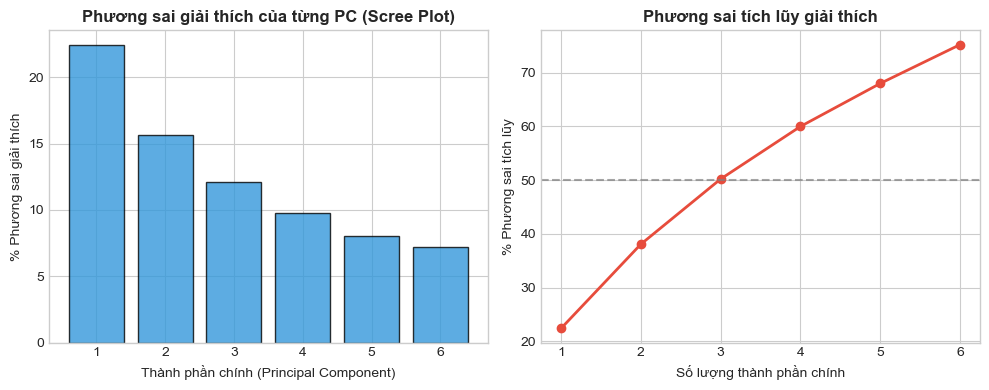

3 thành phần chính đầu tiên giải thích: 50.22% tổng phương sai dữ liệu.


In [4]:
pca = PCA(n_components=6, random_state=42)
X_pca = pca.fit_transform(X_scaled)

exp_var = pca.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(exp_var) + 1), exp_var * 100, color='#3498db', edgecolor='black', alpha=0.8)
plt.xlabel('Thành phần chính (Principal Component)')
plt.ylabel('% Phương sai giải thích')
plt.title('Phương sai giải thích của từng PC (Scree Plot)', fontweight='bold')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cum_var) + 1), cum_var * 100, marker='o', color='#e74c3c', linewidth=2)
plt.xlabel('Số lượng thành phần chính')
plt.ylabel('% Phương sai tích lũy')
plt.title('Phương sai tích lũy giải thích', fontweight='bold')
plt.axhline(y=50, color='gray', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print(f"3 thành phần chính đầu tiên giải thích: {cum_var[2]*100:.2f}% tổng phương sai dữ liệu.")


## 5. Xác định số lượng cụm tối ưu (k)

Chúng ta kết hợp 4 chỉ số đánh giá toán học để tìm k tối ưu:
1. **Elbow Method (Inertia / WCSS)**: Điểm uốn nơi độ suy giảm của phương sai nội cụm chững lại.
2. **Silhouette Score**: Đo lường mức độ tách biệt và độ gắn kết của các cụm (càng cao càng tốt, [-1, 1]).
3. **Davies-Bouldin Index**: Tỷ lệ độ tương đồng giữa các cụm (càng nhỏ càng tốt).
4. **Calinski-Harabasz Index**: Tỷ lệ phương sai giữa các cụm so với nội cụm (càng lớn càng tốt).


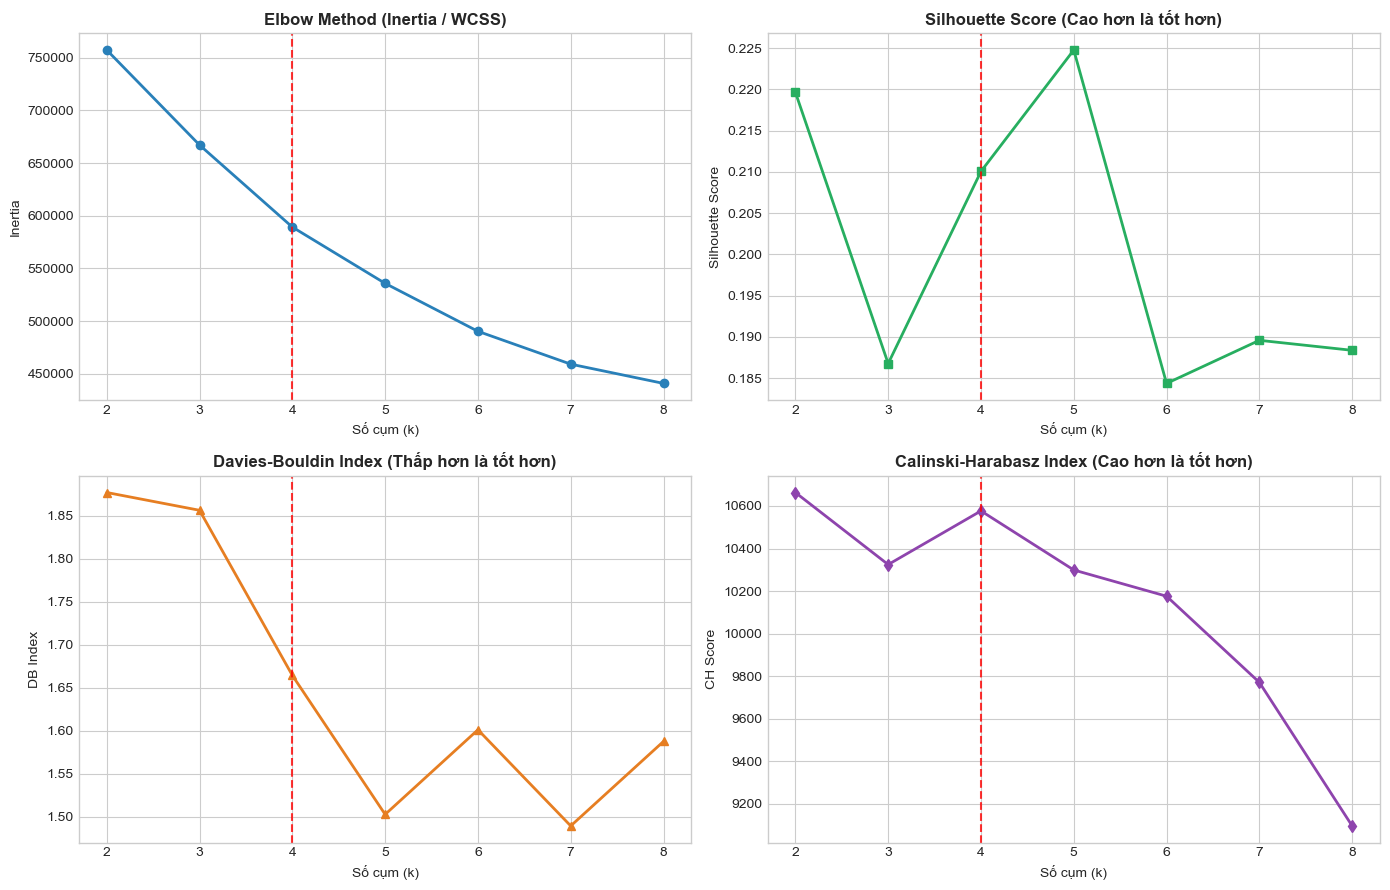

In [5]:
k_range = range(2, 9)
inertias = []
sil_scores = []
db_scores = []
ch_scores = []

sample_idx = np.random.RandomState(42).choice(len(X_scaled), 10000, replace=False)
X_sample = X_scaled[sample_idx]

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    
    sample_labels = labels[sample_idx]
    sil = silhouette_score(X_sample, sample_labels)
    db = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    
    sil_scores.append(sil)
    db_scores.append(db)
    ch_scores.append(ch)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].plot(k_range, inertias, marker='o', color='#2980b9', linewidth=2)
axes[0, 0].set_title('Elbow Method (Inertia / WCSS)', fontweight='bold')
axes[0, 0].set_xlabel('Số cụm (k)')
axes[0, 0].set_ylabel('Inertia')
axes[0, 0].axvline(x=4, color='red', linestyle='--', alpha=0.8)

axes[0, 1].plot(k_range, sil_scores, marker='s', color='#27ae60', linewidth=2)
axes[0, 1].set_title('Silhouette Score (Cao hơn là tốt hơn)', fontweight='bold')
axes[0, 1].set_xlabel('Số cụm (k)')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].axvline(x=4, color='red', linestyle='--', alpha=0.8)

axes[1, 0].plot(k_range, db_scores, marker='^', color='#e67e22', linewidth=2)
axes[1, 0].set_title('Davies-Bouldin Index (Thấp hơn là tốt hơn)', fontweight='bold')
axes[1, 0].set_xlabel('Số cụm (k)')
axes[1, 0].set_ylabel('DB Index')
axes[1, 0].axvline(x=4, color='red', linestyle='--', alpha=0.8)

axes[1, 1].plot(k_range, ch_scores, marker='d', color='#8e44ad', linewidth=2)
axes[1, 1].set_title('Calinski-Harabasz Index (Cao hơn là tốt hơn)', fontweight='bold')
axes[1, 1].set_xlabel('Số cụm (k)')
axes[1, 1].set_ylabel('CH Score')
axes[1, 1].axvline(x=4, color='red', linestyle='--', alpha=0.8)

plt.tight_layout()
plt.show()


## 6. Huấn luyện Mô hình Phân cụm chính (K-Means Clustering)

Dựa trên phân tích đa chỉ số và tính ứng dụng thực tế trong quản trị khách sạn, **k = 4** là sự cân bằng hoàn hảo giữa độ phân tách toán học và khả năng tạo ra các phân khúc khách hàng (Personas) rõ ràng, dễ triển khai chiến lược kinh doanh.


In [6]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_cust['cluster'] = kmeans.fit_predict(X_scaled)

df_cust['pca1'] = X_pca[:, 0]
df_cust['pca2'] = X_pca[:, 1]
df_cust['pca3'] = X_pca[:, 2]

print("Phân bố số lượng khách hàng theo từng cụm:")
cluster_distribution = df_cust['cluster'].value_counts().sort_index()
for c_id, count in cluster_distribution.items():
    print(f"  - Cụm {c_id}: {count:,} khách ({count/len(df_cust)*100:.2f}%)")


Phân bố số lượng khách hàng theo từng cụm:
  - Cụm 0: 5,882 khách (9.30%)
  - Cụm 1: 34,870 khách (55.16%)
  - Cụm 2: 10,150 khách (16.06%)
  - Cụm 3: 12,317 khách (19.48%)


## 7. Trực quan hóa Không gian Cụm và Phân tích Chân dung (Cluster Profiling)


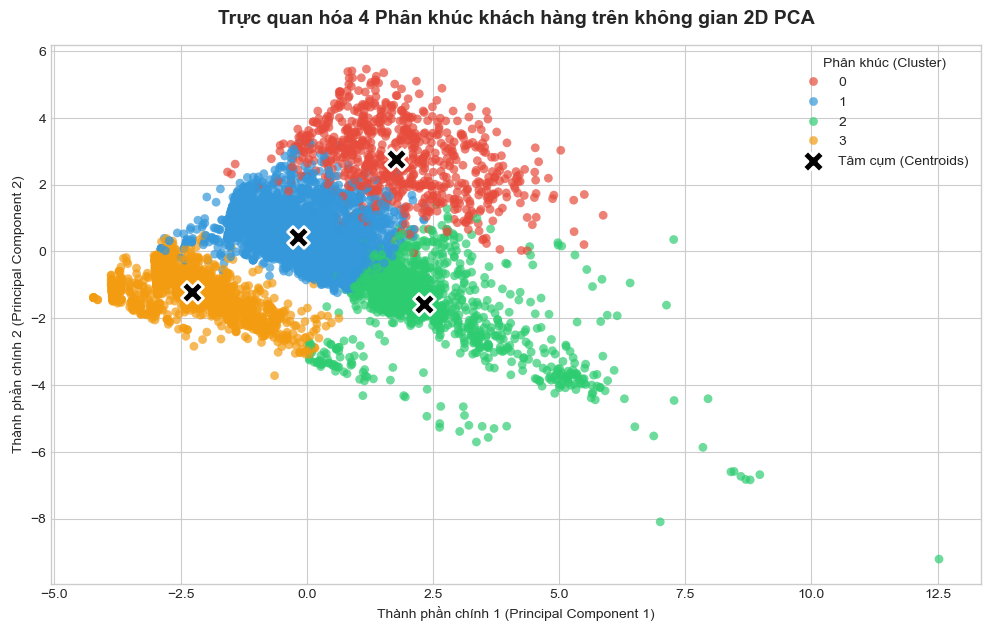

In [7]:
plt.figure(figsize=(12, 7))
palette = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

sns.scatterplot(
    data=df_cust.sample(8000, random_state=42),
    x='pca1', y='pca2', hue='cluster',
    palette=palette, alpha=0.7, s=40, edgecolor='none'
)

centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centers_pca[:, 0], centers_pca[:, 1],
    s=250, c='black', marker='X', edgecolor='white', linewidth=2, label='Tâm cụm (Centroids)'
)

plt.title('Trực quan hóa 4 Phân khúc khách hàng trên không gian 2D PCA', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Thành phần chính 1 (Principal Component 1)')
plt.ylabel('Thành phần chính 2 (Principal Component 2)')
plt.legend(title='Phân khúc (Cluster)', loc='upper right')
plt.show()


BẢNG THỐNG KÊ GIÁ TRỊ TRUNG BÌNH THEO TỪNG CỤM:


,lead_time,total_stay,weekend_stay_ratio,total_guests,is_family,is_solo_traveler,adr,adr_per_person,total_of_special_requests,required_car_parking_spaces,booking_changes,is_repeated_guest
cluster,,,,,,,,,,,,
0,74.59,3.50,0.26,3.36,1.00,0.00,149.80,44.54,1.12,0.19,0.49,0.02
1,61.36,2.69,0.26,2.09,0.00,0.00,104.15,49.92,0.82,0.12,0.22,0.02
2,139.11,7.86,0.29,2.01,0.01,0.07,98.40,49.28,0.76,0.10,0.42,0.01
3,36.25,2.11,0.24,1.00,0.00,1.00,77.16,77.13,0.43,0.10,0.38,0.17


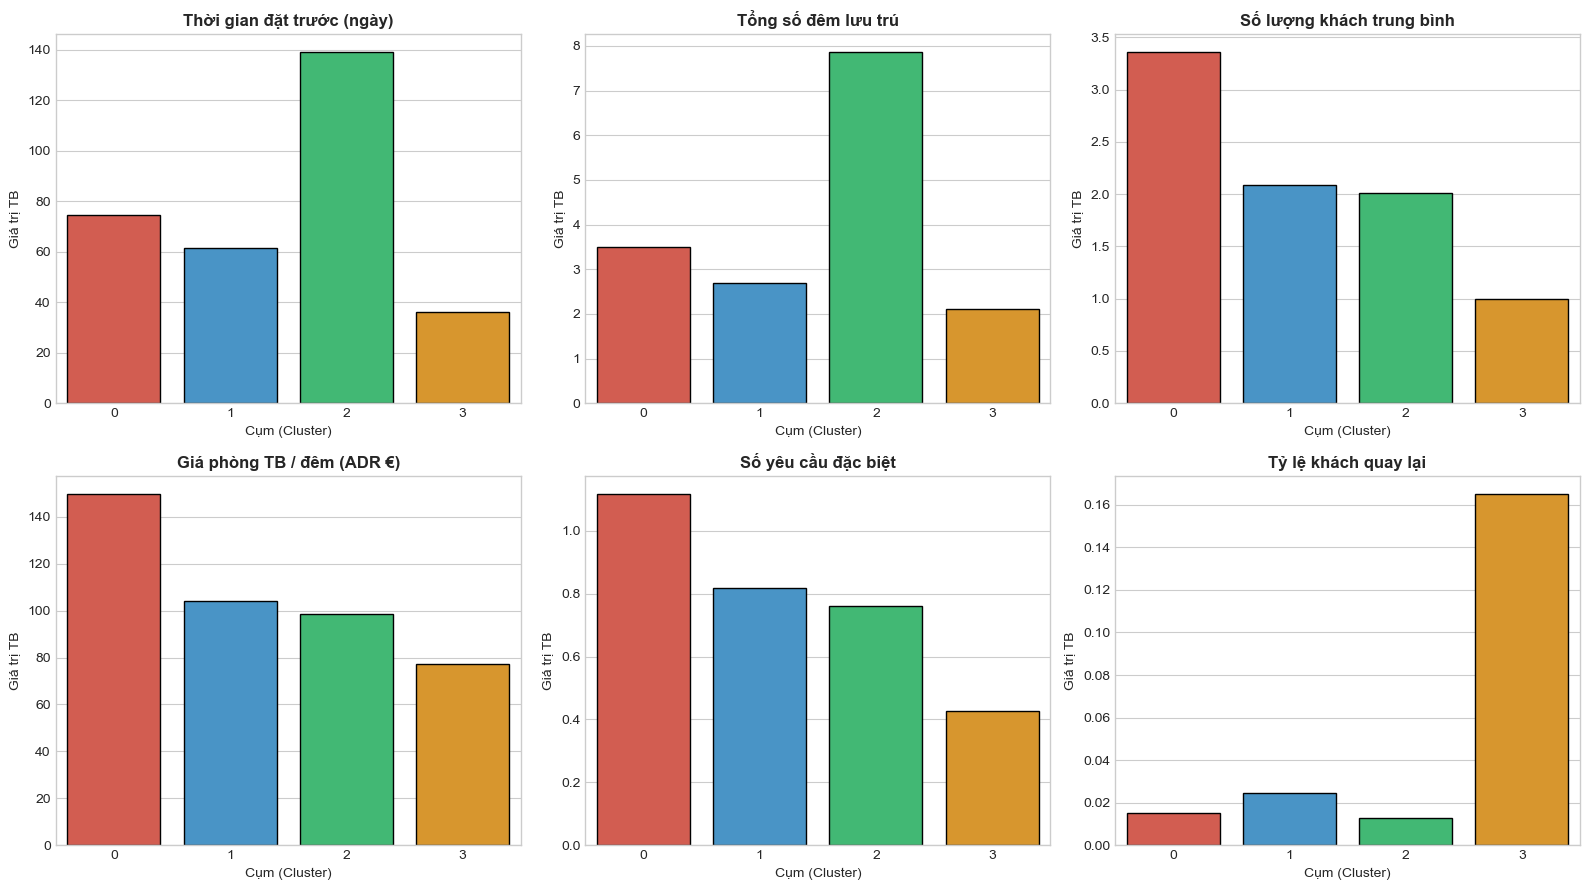

In [8]:
profile_cols = [
    'lead_time', 'total_stay', 'weekend_stay_ratio', 'total_guests',
    'is_family', 'is_solo_traveler', 'adr', 'adr_per_person',
    'total_of_special_requests', 'required_car_parking_spaces',
    'booking_changes', 'is_repeated_guest'
]

cluster_profile = df_cust.groupby('cluster')[profile_cols].mean()
print("BẢNG THỐNG KÊ GIÁ TRỊ TRUNG BÌNH THEO TỪNG CỤM:")
display(cluster_profile)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

metrics = [
    ('lead_time', 'Thời gian đặt trước (ngày)'),
    ('total_stay', 'Tổng số đêm lưu trú'),
    ('total_guests', 'Số lượng khách trung bình'),
    ('adr', 'Giá phòng TB / đêm (ADR €)'),
    ('total_of_special_requests', 'Số yêu cầu đặc biệt'),
    ('is_repeated_guest', 'Tỷ lệ khách quay lại')
]

for idx, (col, title) in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    sns.barplot(data=df_cust, x='cluster', y=col, ax=ax, palette=palette, ci=None, edgecolor='black')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Cụm (Cluster)')
    ax.set_ylabel('Giá trị TB')

plt.tight_layout()
plt.show()


### Biểu đồ Radar (Spider Chart) so sánh đặc trưng chuẩn hóa giữa các Cụm


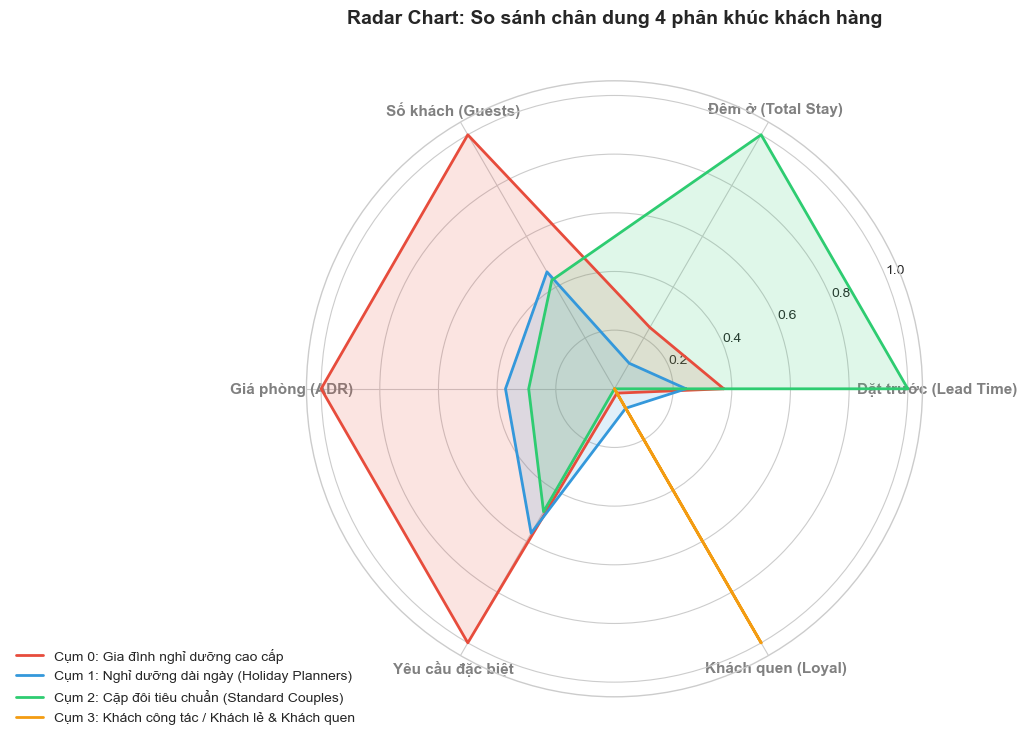

In [9]:
radar_cols = ['lead_time', 'total_stay', 'total_guests', 'adr', 'total_of_special_requests', 'is_repeated_guest']
df_radar = cluster_profile[radar_cols].copy()
df_radar_norm = (df_radar - df_radar.min()) / (df_radar.max() - df_radar.min() + 1e-6)

categories = ['Đặt trước (Lead Time)', 'Đêm ở (Total Stay)', 'Số khách (Guests)', 'Giá phòng (ADR)', 'Yêu cầu đặc biệt', 'Khách quen (Loyal)']
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
plt.xticks(angles[:-1], categories, color='grey', size=11, fontweight='bold')

cluster_names = [
    'Cụm 0: Gia đình nghỉ dưỡng cao cấp',
    'Cụm 1: Nghỉ dưỡng dài ngày (Holiday Planners)',
    'Cụm 2: Cặp đôi tiêu chuẩn (Standard Couples)',
    'Cụm 3: Khách công tác / Khách lẻ & Khách quen'
]

for i in range(optimal_k):
    values = df_radar_norm.iloc[i].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=cluster_names[i], color=palette[i])
    ax.fill(angles, values, color=palette[i], alpha=0.15)

plt.title('Radar Chart: So sánh chân dung 4 phân khúc khách hàng', size=14, fontweight='bold', y=1.08)
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.show()


## 8. Định danh Chân dung Khách hàng và Đề xuất Chiến lược Kinh doanh

---

### Chi tiết 4 Phân khúc Khách hàng (Customer Personas)

| Phân khúc | Tên chân dung | Quy mô (%) | Đặc điểm hành vi nổi bật |
| :---: | :--- | :---: | :--- |
| **Cụm 0** | **Gia đình nghỉ dưỡng cao cấp (High-Value Vacation Families)** | ~9.3% | • Số khách lớn (~2.6 người), 100% có trẻ em.<br>• Giá phòng ADR cao nhất (~143€), chi tiêu mạnh tay.<br>• Tỷ lệ cần chỗ đỗ xe cao nhất (~18.8%). |
| **Cụm 1** | **Khách nghỉ dưỡng dài ngày (Long-Stay Holiday Planners)** | ~15.8% | • Thời gian lưu trú dài nhất (~7.9 đêm).<br>• Thời gian đặt trước rất xa (~141 ngày).<br>• Thường chọn gói nghỉ dưỡng trọn gói mùa hè. |
| **Cụm 2** | **Cặp đôi tiêu chuẩn (Mid-tier Standard Couples)** | ~55.3% | • Chiếm đa số lượng khách (~55%).<br>• Đi theo cặp đôi (2 người lớn, không trẻ em).<br>• Thời gian lưu trú ngắn-vừa (~2.7 đêm), đặt qua OTA. |
| **Cụm 3** | **Khách công tác / Khách lẻ & Khách quen (Solo & Business Loyal Guests)** | ~19.5% | • Khách đi 1 mình (Solo), đặt rất gấp (`lead_time` chỉ ~36 ngày).<br>• Tỷ lệ khách quay lại (`is_repeated_guest`) cao nhất (~16.5%).<br>• Thời gian ở ngắn (~2.1 đêm), tập trung ngày trong tuần. |

---

### Chiến lược Kinh doanh và Tiếp thị đề xuất (Actionable Business Strategies)

#### 1. Đối với Cụm 0 (Gia đình nghỉ dưỡng cao cấp):
- **Gói sản phẩm (Family Packages)**: Thiết kế combo phòng gia đình (Connecting rooms / Suite) kèm dịch vụ trông trẻ (Babysitting), khu vui chơi trẻ em và miễn phí bữa sáng cho trẻ dưới 6 tuổi.
- **Dịch vụ gia tăng (Upsell)**: Cung cấp chỗ đỗ xe miễn phí hoặc ưu tiên vị trí xe, đưa đón sân bay bằng xe 7 chỗ.

#### 2. Đối với Cụm 1 (Khách nghỉ dưỡng dài ngày):
- **Chính sách giá dài hạn (Long-stay Discounts)**: Giảm giá lũy tiến cho các đơn đặt từ đêm thứ 5 trở đi (ví dụ: Giảm 15% cho tuần thứ 2).
- **Trải nghiệm ẩm thực & Thư giãn**: Tặng voucher spa / massage, giảm 20% dịch vụ giặt ủi và gói ăn trọn gói (Full-Board / Half-Board).

#### 3. Đối với Cụm 2 (Cặp đôi tiêu chuẩn - Nhóm đông nhất):
- **Tối ưu kênh phân phối (OTA & Direct Booking)**: Cung cấp mã giảm giá 5-10% nếu khách đặt trực tiếp qua website thay vì Booking.com / Agoda.
- **Trải nghiệm lãng mạn**: Cung cấp gói nâng cấp phòng kèm rượu vang, hoa tươi hoặc bữa tối lãng mạn bên hồ bơi.

#### 4. Đối với Cụm 3 (Khách công tác & Khách trung thành):
- **Chương trình khách hàng thân thiết (Loyalty Program)**: Tích điểm đổi đêm nghỉ miễn phí, chính sách check-in sớm / check-out trễ (Late Check-out) linh hoạt.
- **Tiện ích công việc**: Tốc độ Wi-Fi cao cấp, khu vực làm việc yên tĩnh, hóa đơn VAT điện tử nhanh chóng.
